In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D#导入二维仿射变换对象,基于坐标的变换工具

In [2]:
def fibonacci(n):
    if n<= 1:
        return n
    else:
        return fibonacci(n - 1) + fibonacci(n-2)

In [3]:
num = 9
idx_array = np.arange(num)
fibonaccI_array = np.array([fibonacci(i) for i in range(num)])

In [16]:
fibonacci_array_from_1 = np.array([fibonacci(i) for i in np.arange(1,num + 1)])

In [17]:
x_array = 0 + fibonacci_array_from_1*(-1) ** (np.floor(idx_array/2)+2)
x_array = np.insert(x_array,0,0)#指定为支插值
x_array = np.cumsum(x_array)#求和

In [29]:
y_array = 0 + fibonacci_array_from_1 * (-1) ** (np.floor((1 + idx_array)/2)+1)
y_array = np.insert(y_array,0,0)#在索引为0的位置插入0
y_array = np.cumsum(y_array)

In [30]:
rotation = (idx_array - 1)*90

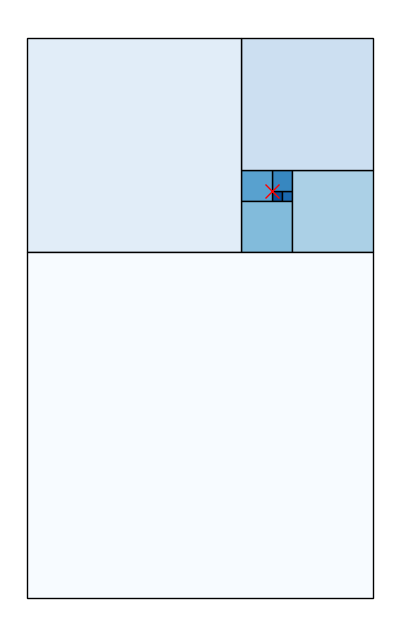

In [31]:
fig,ax = plt.subplots(figsize = (8,8))
#plt的cm就是matplotlib.cm的转发引用
colors = plt.cm.Blues_r(np.linspace(0,1,num+1))

for i in idx_array:
    rotate_i = rotation[i]
    side_idx = fibonacci_array_from_1[i]
    rec_loc_idx = np.array([x_array[i],y_array[i]])

    rec = plt.Rectangle(rec_loc_idx,
                       width = side_idx,
                       height = side_idx,
                       facecolor = colors[i+1],
                       edgecolor = 'k',
                        #进行仿射变换
                        #根据交租自动进行仿射变换(生成了中间的矩阵)
                        #最后的ax.transData将数据坐标转换为画布坐标,mpl绘图中这里不是矩阵加法,表示先用A再用B
                            #这里A就是数据坐标,B表示数据坐标在ax坐标下
                            #+表示变化的组合,不是矩阵相加
                       transform = Affine2D().rotate_deg_around(
                           x_array[i],y_array[i],rotate_i)+ax.transData)
    ax.add_patch(rec)

ax.set_aspect('equal')
ax.plot(0,0,color = 'r',marker = 'x',markersize = 10)
ax.axis('off')
plt.show()

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D

In [35]:
def fibonacci(n):
    if n<= 1:
        return n
    else:
        return fibonacci(n - 1) + fibonacci(n-2)

num = 11
idx_array = np.arange(num)
fibonacci_array = np.array([fibonacci(i) for i in range(num)])

fibonacci_array_from_1 = np.array([fibonacci(i) for i in np.arange(1,num + 1)])

x_array = 0 + fibonacci_array_from_1*(-1) ** (np.floor(idx_array/2)+2)
x_array = np.insert(x_array,0,0)#指定为支插值
x_array = np.cumsum(x_array)#求和

y_array = 0 + fibonacci_array_from_1 * (-1) ** (np.floor((1 + idx_array)/2)+1)
y_array = np.insert(y_array,0,0)#在索引为0的位置插入0
y_array = np.cumsum(y_array)

rotation = (idx_array - 1)*90

In [39]:
x_arc_center = fibonacci_array * (4*np.abs((idx_array - 1) /4 - np.floor((idx_array - 1)/4 + 2/4)) - 1)
x_arc_center = np.cumsum(x_arc_center) + 1
x_arc_center = np.insert(x_arc_center,0,1)

triangle_wave = 4*np.abs((idx_array - 1)/4 - np.floor((idx_array - 1)/4 + 2/4)) - 1
triangle_wave = np.insert(triangle_wave,0,0)

y_arc_center = fibonacci_array * triangle_wave[:-1]
y_arc_center = np.cumsum(y_arc_center) + 0
y_arc_center = np.insert(y_arc_center,0,0)

In [45]:
def plot_arc(x_i,y_i,r_i,rotation_i):
    rotation_i = rotation_i / 180 * np.pi
    angle_array = np.linspace(rotation_i,
                              rotation_i + np.pi/2,
                             101,endpoint = True)
    x_arc_array = r_i * np.cos(angle_array) + x_i
    y_arc_array = r_i * np.sin(angle_array) + y_i
    plt.plot(x_arc_array,y_arc_array,c = 'k')

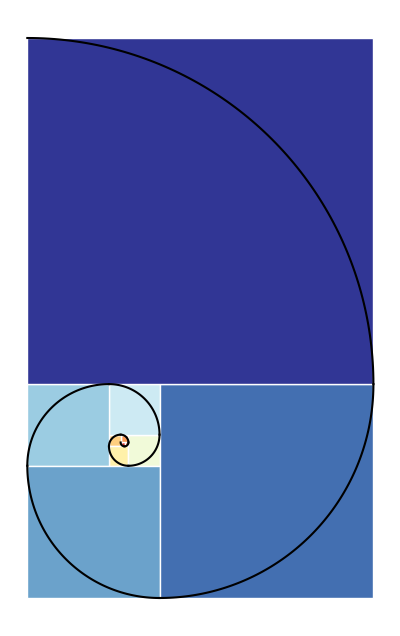

In [46]:
fig,ax = plt.subplots(figsize = (8,8))
colors = plt.cm.RdYlBu(np.linspace(0,1,num+1))

for i in idx_array:
    rotate_i = rotation[i]
    side_idx = fibonacci_array_from_1[i]
    rec_loc_idx = np.array([x_array[i],y_array[i]])

    rec = plt.Rectangle(rec_loc_idx,
                       width = side_idx,
                       height = side_idx,
                       facecolor = colors[i+1],
                       edgecolor = 'w',
                       transform = Affine2D().rotate_deg_around(
                           x_array[i],y_array[i],rotate_i)+ax.transData)
    ax.add_patch(rec)
    plot_arc(x_arc_center[i],y_arc_center[i],
             fibonacci_array_from_1[i],180+i*90)

ax.set_aspect('equal')
ax.axis('off')
plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

In [76]:
def get_vertex(p1,p2):
    theta = 60
    theta = theta * np.pi/180
    R = np.array([[np.cos(theta), - np.sin(theta)],
                  [np.sin(theta),   np.cos(theta)]])
    v = p2 - p1
    p3 = p1 + R @ v
    return p3

def draw_triangle(triangle,color):
    v0,v1,v2 = triangle
    poly = Polygon((v0,v1,v2),
                  facecolor = color,
                  edgecolor = 'k',
                  linewidth = 2,
                   #拐角样式,这里是削角
                  joinstyle = 'bevel')

    ax.add_patch(poly)

In [71]:
num = 12
P = [1,1,1,2]
#在4-12之间,不包括12生成整数的迭代器
for i in range(4,num):
    P.append(P[i - 2] + P[i - 3])

print(P)

[1, 1, 1, 2, 2, 3, 4, 5, 7, 9, 12, 16]


In [72]:
V0 = np.array([0,0])
V1 = np.array([1,0])
V2 = get_vertex(V0,V1)
V3 = get_vertex(V2,V1)
V4 = get_vertex(V2,V3)
V5 = get_vertex(V0,V4)
V6 = get_vertex(V0,V5)
V7 = get_vertex(V1,V6)

In [73]:
#固定形状的数据,但是没有初始化(随机垃圾数据),形状固定,只能整体切片赋值,不能append
T = np.empty((num,3,2))

T[:6] = [(V0,V1,V2),
         (V2,V1,V3),
         (V2,V3,V4),
         (V0,V4,V5),
         (V0,V5,V6),
         (V1,V6,V7)]

In [74]:
for i in range(6,num):
    V0,V1 = T[i - 4][1],T[i - 1][2]
    T[i] = (V0,V1,get_vertex(V0,V1))

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


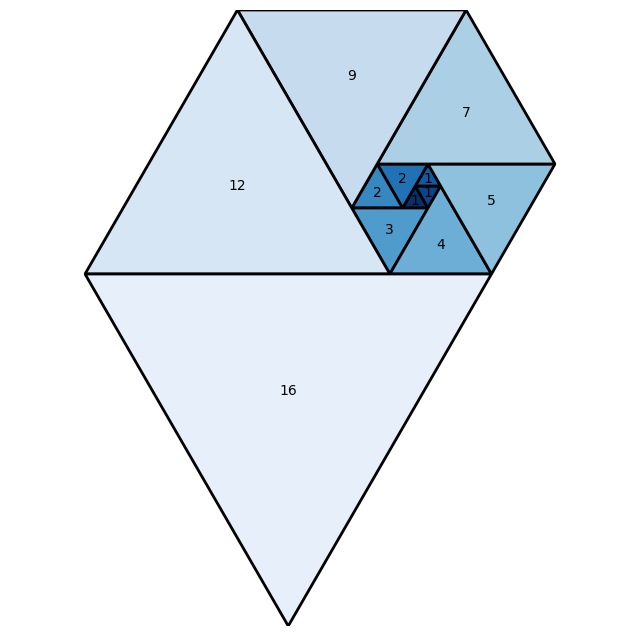

In [85]:
fig,ax = plt.subplots(figsize = (8,8))

colors = plt.cm.Blues_r(np.linspace(0,1,len(T) + 1))

for i in range(len(T)):
    draw_triangle(T[i],colors[i])
    ax.annotate(str(P[i]),np.mean(T[i],axis = 0),
               va = 'center',ha = 'center')

ax.axis('equal')
xmax = np.max(T[:,:,0])
xmin = np.min(T[:,:,0])
ymax = np.max(T[:,:,1])
ymin = np.min(T[:,:,1])
ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)
ax.axis('off')
plt.show()

In [86]:
import numpy as np
import matplotlib.pyplot as plt

In [91]:
def recaman(n):
    #列表乘以一个值表示列表重复运算,不是广播
    #创建一个列表有n个0
    #只有在array下np.array([0]) * n为[0],这是矩阵数值运算,[0]被看成矩阵标量
    arr = [0] * n
    arr[0] = 0 #冗余操作,已经为0了
    print(arr[0],end = ',')#默认结尾是换行符,这里打印为','

    for i in range(1,n):
        curr = arr[i - 1] - i
        for j in range(0,i):
            if ((arr[j] == curr) or curr < 0):
                curr = arr[i - 1] + i
                break

        arr[i] = curr
        print(arr[i],end = ',')

    return arr

In [92]:
num_iterations = 1000
recamans_sq = recaman(num_iterations)

0,1,3,6,2,7,13,20,12,21,11,22,10,23,9,24,8,25,43,62,42,63,41,18,42,17,43,16,44,15,45,14,46,79,113,78,114,77,39,78,38,79,37,80,36,81,35,82,34,83,33,84,32,85,31,86,30,87,29,88,28,89,27,90,26,91,157,224,156,225,155,226,154,227,153,228,152,75,153,74,154,73,155,72,156,71,157,70,158,69,159,68,160,67,161,66,162,65,163,64,164,265,367,264,368,263,369,262,370,261,151,40,152,265,379,494,378,495,377,258,138,259,137,260,136,261,135,262,134,5,135,4,136,269,403,268,132,269,131,270,130,271,129,272,128,273,127,274,126,275,125,276,124,277,123,278,122,279,121,280,120,281,119,282,118,283,117,284,116,285,115,286,458,631,457,632,456,633,455,634,454,635,453,636,452,267,453,266,454,643,833,642,450,257,451,256,60,257,59,258,58,259,57,260,56,261,55,262,54,263,53,264,52,265,51,266,50,267,49,268,48,269,47,270,494,719,493,720,492,721,491,722,490,723,489,254,490,253,491,252,492,251,493,250,494,249,495,248,496,247,497,246,498,245,499,244,500,243,501,242,502,241,503,240,504,239,505,238,506,237,507,236,508,235,509,234

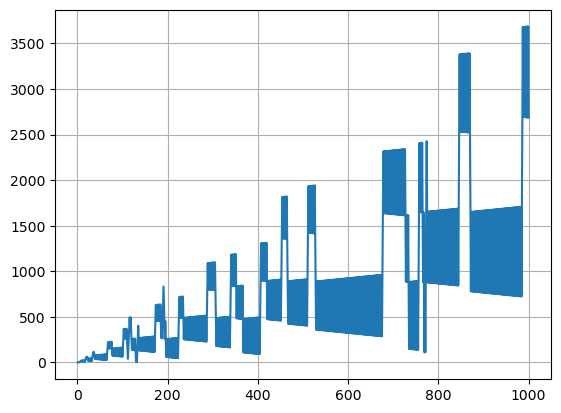

In [93]:
fig,ax = plt.subplots()
ax.plot(np.arange(1,len(recamans_sq) + 1),recamans_sq)
plt.grid()
plt.show()

In [98]:
def add_to_plot(last_a,a,n):
    c,r = (a+last_a) / 2,abs(a - last_a) / 2
    y = np.linspace(-r,r,1000)
    x = np.sqrt(r ** 2 - y ** 2) * (-1) **n
    color = cm(n / max_terms)
    ax.plot(x,y+c,c = color,lw =1)

/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_42011/499196908.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('hsv')


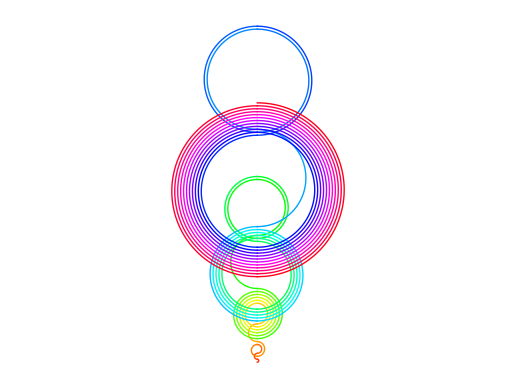

In [99]:
fig,ax = plt.subplots()
ax.axis('equal')
ax.axis('off')
cm = plt.cm.get_cmap('hsv')

seen = []
n = a = 0
lasta = None
max_terms = 60
while n < max_terms:
    last_a = a
    if (b := a - n) > 0 and b not in seen:
        a = b
    else:
        a = a + n
    seen = seen + [a]
    n += 1
    add_to_plot(last_a,a,n)
ax.set_yticks(np.arange(np.array(seen).max() + 1,step = 5))